# Topic analysis Ages v3 test — Final
## One selected method per corpus

This notebook shows the **number and percentage of papers in each publication-year bin
within each cluster**: **2020–2026, 2010–2019, 2000–2009, ≤1999**.

| Corpus | Method | Saved setting | Assigned clusters |
|---|---|---|---|
| PDFs | Embedding Leiden | resolution **0.95** | 5 |
| Broad abstracts (**1,531 papers**) | K-means | **k = 6** | 6 |
| Citations | Citation Leiden | resolution **0.9** | 5 |

The abstract partition comes from **Clustering Abstracts Test 1531.ipynb**.
`configs/topic-age-final-inputs.json` pins its exact saved experiment and manifest
checksum. Memberships are loaded by paper ID and validated against the retained
CSV and embedding matrix. No clustering is performed here, globally or inside bins.

The PDF and citation partitions retain their existing memberships. Elite Papers
Abstracts are a separate workflow. Historical reports are archived; this report
contains only the three selected corpus/method combinations.

Each cluster is labelled with its **top eight two-word expressions**, recomputed
from that exact partition using the v2 topic-analysis ranking and support settings.
The six abstract labels use only the 1,531 retained texts; names from the older
corpus are not reused. Labels remain fixed across all publication-year bins.
Cluster numbers identify groups only within their own partition.


In [1]:
from pathlib import Path
from importlib import reload
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/batill').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the batill project.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
# Refresh helpers in running kernels so earlier notebook versions cannot linger.
import batill.abstract_topic_explorer as abstract_explorer
import batill.citation_topic_explorer as citation_explorer
import batill.topic_analysis as topic_analysis
import batill.topic_explorer as topic_explorer
import batill.abstract_experiment as abstract_experiment
import batill.topic_age_v2 as age_analysis
import batill.topic_age_names as age_names
reload(abstract_explorer)
reload(citation_explorer)
reload(topic_analysis)
reload(topic_explorer)
reload(abstract_experiment)
reload(age_analysis)
reload(age_names)
from batill.storage import read_json
from batill.topic_age_v2 import (
    load_memberships, bin_tables, bin_matrix, plot_partition_bins, export_results,
)
from batill.topic_age_names import load_named_memberships, plot_named_bins
CONFIG = read_json(ROOT / 'configs/topic-age-final-inputs.json')
OUT = ROOT / 'reports/topic_age_analysis_v3_test_final'
FIGURES = OUT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)


## 1 Year bins and publication dates

Boundaries are inclusive. The newest bin covers **2020 through 2026**, followed
by the two earlier decades and all publications through 1999. The bins have
unequal durations; counts show corpus composition, not annual publication rates.
2026 is incomplete.

PDFs and citations use the saved **OpenAlex publication year**, exactly as verbal
complexity does. Abstracts use their saved **Scopus year**. Years are joined by
stable paper identities and validated; missing, future or invalid years cause an
error instead of silently removing papers or switching to another date source.


In [2]:
display(pd.DataFrame(CONFIG['periods']).rename(columns={
    'label': 'Year bin', 'start': 'First year (inclusive)', 'end': 'Last year (inclusive)',
}).style.hide(axis='index'))
print('Fixed reference year:', CONFIG['reference_year'])
print('The ≤1999 bin includes every valid year up to 1999 in these corpora.')


Fixed reference year: 2026
The ≤1999 bin includes every valid year up to 1999 in these corpora.


Year bin,First year (inclusive),Last year (inclusive)
2020–2026,2020,2026
2010–2019,2010,2019
2000–2009,2000,2009
≤1999,1800,1999


## 2 Load the three selected memberships

The table below records the saved resolution, seed, cluster count and population
actually used. Abstract K-means has six clusters (IDs 0–5); PDF and citation Leiden
have five assigned clusters each (IDs 1–5). Citation cluster 0 is unassigned and
reported separately.

The PDF and citation corpora each contain 292 canonical works. The broad abstract
corpus contains **1,531 records**. Shares are calculated separately for each corpus.
PDF and citation populations overlap, so totals must not be added across corpora.

**Expression labels:** the v2 workbooks supply ranking and support settings only.
TF-IDF contrast and the top eight two-word expressions are computed afresh on each
selected partition. The abstract setting source remains the Final topic workbook,
but the text and memberships come exclusively from the pinned 1,531-paper experiment.
Labels are never transferred solely by cluster number.


In [3]:
TOP_EXPRESSIONS = 8
members, selected_partitions, provenance, cluster_names, label_evidence = load_named_memberships(
    ROOT, CONFIG, top_n=TOP_EXPRESSIONS,
)
assert len(selected_partitions) == 3
assert selected_partitions.analysis.is_unique
assert set(zip(selected_partitions.analysis, selected_partitions.solution)) == {
    ('pdfs', 'embedding_leiden_k5'), ('abstracts', 'kmeans_k6'), ('citations', 'citation_r0.9')}
abstract_members = members.loc[members.analysis.eq('abstracts')]
assert len(abstract_members) == 1531 and abstract_members.paper_id.is_unique
assert set(abstract_members.cluster) == set(range(6))
counts, coverage = bin_tables(members, CONFIG['periods'], share_basis=CONFIG['share_basis'])
display(selected_partitions[['partition', 'clusters', 'resolution', 'seed',
                             'papers', 'assigned', 'unassigned']]
        .style.hide(axis='index').format({'resolution': '{:.2f}'}, na_rep='—'))
print('All selected memberships loaded and validated; no clustering performed.')

print(f'Expression labels: {len(cluster_names)} clusters; up to {TOP_EXPRESSIONS} two-word expressions each.')
for spec in CONFIG['partitions']:
    display(Markdown(f"### {spec['label']} — cluster names"))
    name_rows = cluster_names.loc[cluster_names.analysis.eq(spec['analysis'])
                                 & cluster_names.solution.eq(spec['solution'])]
    display(name_rows[['cluster', 'topic_name']].rename(columns={
        'cluster': 'Cluster ID', 'topic_name': 'Top 8 two-word expressions (rank order)',
    }).style.hide(axis='index').set_properties(**{'white-space': 'normal'}))


All selected memberships loaded and validated; no clustering performed.
Expression labels: 16 clusters; up to 8 two-word expressions each.


partition,clusters,resolution,seed,papers,assigned,unassigned
PDFs · Leiden 0.95,5,0.95,44,292,292,0
"Abstracts (1,531) · K-means k=6",6,—,22,1531,1531,0
Citations · Leiden 0.9,5,0.90,44,292,289,3


### PDFs · Leiden 0.95 — cluster names

Cluster ID,Top 8 two-word expressions (rank order)
1,pe backed · pe investors · employment growth · pe firms · pe ownership · backed firms · non pe · firm level
2,leveraged buyouts · industry adjusted · post buyout · capital expenditures · operating performance · book value · post lbo · operating cash
3,going public · going private · private firms · firms going · public firms · private firm · compliance costs · sarbanes oxley
4,vintage year · buyout funds · vc funds · fund size · fund performance · committed capital · vintage years · capital funds
5,health care · nursing homes · physician practices · nursing home · equity acquisition · care delivery · pe owned · acquired hospitals


### Abstracts (1,531) · K-means k=6 — cluster names

Cluster ID,Top 8 two-word expressions (rank order)
0,leveraged buyouts · leveraged buyout · secondary buyouts · equity buyouts · value creation · equity firms · target firms · cross border
1,real estate · fund performance · equity funds · fund managers · equity returns · risk adjusted · buyout funds · equity performance
2,equity placements · equity investors · equity industry · equity firms · private placements · equity investments · public equity · private placement
3,venture capital · venture capitalists · early stage · start ups · small business · capital markets · case studies · hedge funds
4,equity firm · smurfit group · jefferson smurfit · madison dearborn · chemical industry · blackstone group · capital partners · equity group
5,pe firms · pe investors · pe backed · pe investment · pe investments · pe vc · pe funds · vc pe


### Citations · Leiden 0.9 — cluster names

Cluster ID,Top 8 two-word expressions (rank order)
1,health care · nursing homes · pe owned · nursing home · pe ownership · pe acquisitions · pe firms · physician practices
2,free cash · going private · management buyouts · operating performance · leveraged buyouts · private transactions · lbo firms · operating income
3,financial reporting · financial statement · financial statements · private firms · statement information · reporting quality · backed ipos · external equity
4,buyout funds · vc funds · vintage year · fund size · fund performance · fund level · vintage years · committed capital
5,practice management · physician practice · hospital systems · physician led · market forces · employed physicians · road ahead · physicians foundation


## 3 Year distribution within each cluster

Each table cell is **count (percentage of that cluster)**:

`percentage = papers in this cluster and year bin / all papers in this cluster × 100`

The year-bin percentages sum to 100% across each cluster's row (subject to display
rounding). A bin with no papers in a cluster is shown as **0 (0.0%)**.
All selected clusters and all four year bins remain visible.

Table and heatmap rows use the full expression labels, with the original cluster
ID kept for reference. The left panel shows exact counts; each bar in the right
panel represents one cluster, split into coloured publication-year bins.
Year-bin colours are consistent across all three corpora. `n` beside each bar is
the total number of papers in that cluster, the percentage denominator.
Three citation isolates are excluded from the cluster distributions and listed in section 4.


### PDFs · Leiden 0.95

period,2020–2026,2010–2019,2000–2009,≤1999
display_cluster,,,,
Cluster 1 — pe backed · pe investors · employment growth · pe firms · pe ownership · backed firms · non pe · firm level,21 (28.8%),37 (50.7%),14 (19.2%),1 (1.4%)
Cluster 2 — leveraged buyouts · industry adjusted · post buyout · capital expenditures · operating performance · book value · post lbo · operating cash,5 (8.1%),34 (54.8%),4 (6.5%),19 (30.6%)
Cluster 3 — going public · going private · private firms · firms going · public firms · private firm · compliance costs · sarbanes oxley,8 (25.8%),11 (35.5%),10 (32.3%),2 (6.5%)
Cluster 4 — vintage year · buyout funds · vc funds · fund size · fund performance · committed capital · vintage years · capital funds,37 (38.1%),48 (49.5%),12 (12.4%),0 (0.0%)
Cluster 5 — health care · nursing homes · physician practices · nursing home · equity acquisition · care delivery · pe owned · acquired hospitals,22 (75.9%),7 (24.1%),0 (0.0%),0 (0.0%)


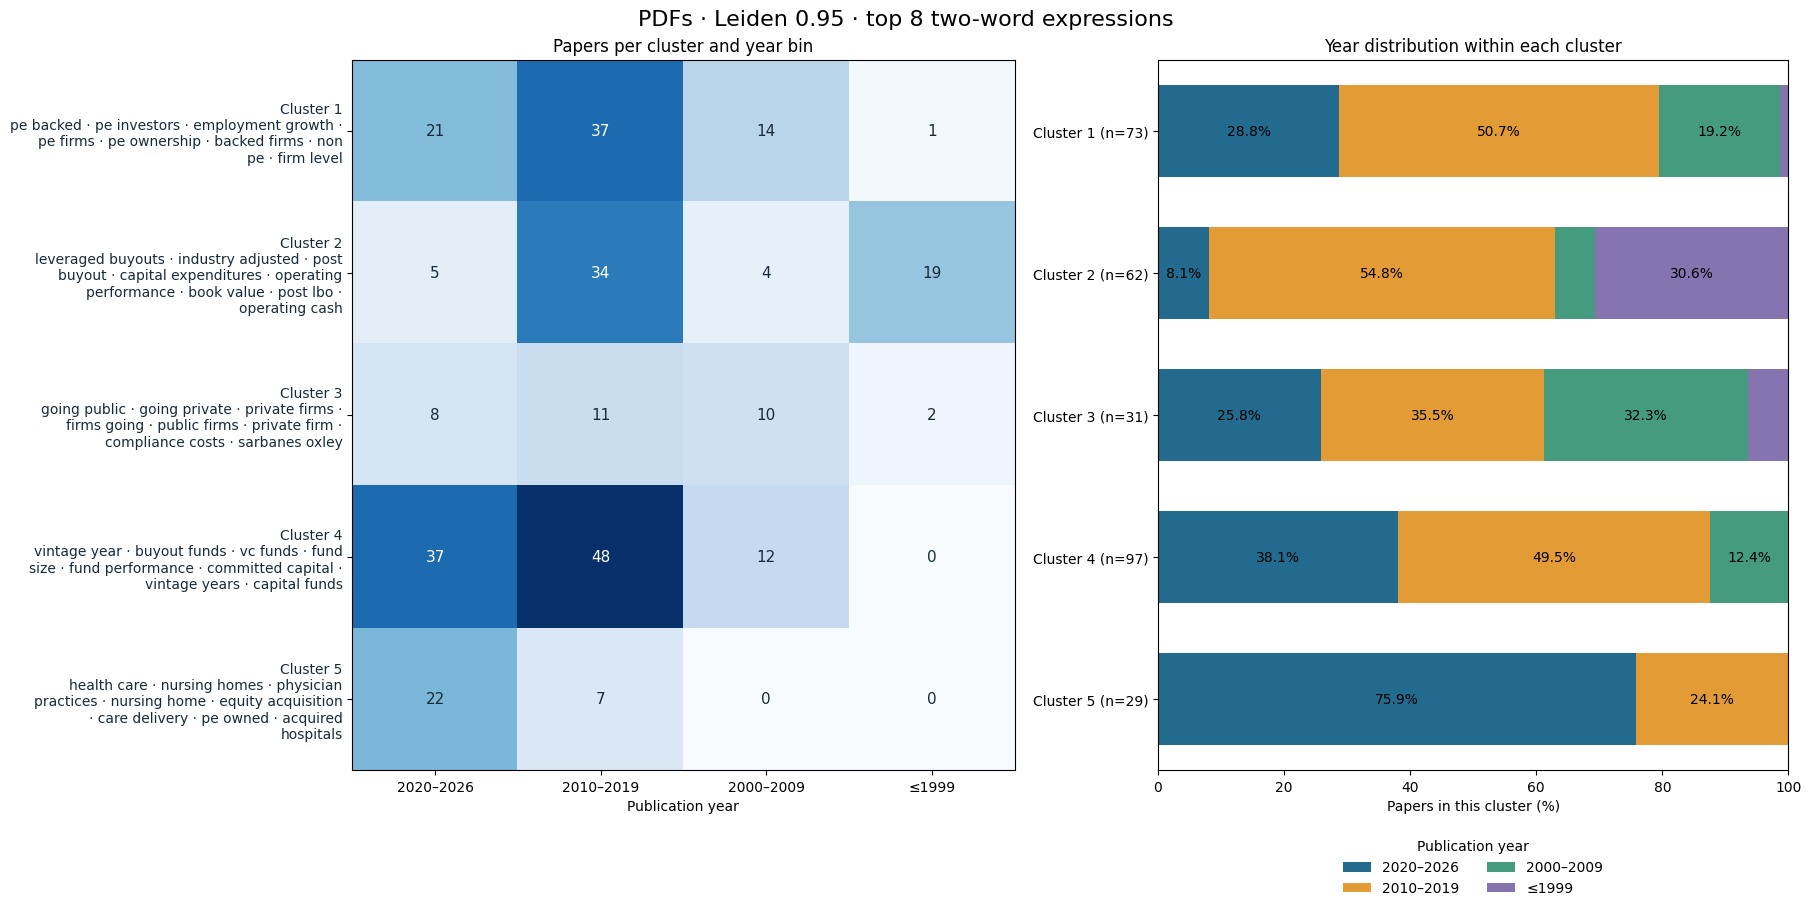

### Abstracts (1,531) · K-means k=6

period,2020–2026,2010–2019,2000–2009,≤1999
display_cluster,,,,
Cluster 0 — leveraged buyouts · leveraged buyout · secondary buyouts · equity buyouts · value creation · equity firms · target firms · cross border,79 (34.5%),132 (57.6%),18 (7.9%),0 (0.0%)
Cluster 1 — real estate · fund performance · equity funds · fund managers · equity returns · risk adjusted · buyout funds · equity performance,136 (46.1%),131 (44.4%),27 (9.2%),1 (0.3%)
Cluster 2 — equity placements · equity investors · equity industry · equity firms · private placements · equity investments · public equity · private placement,94 (27.3%),170 (49.4%),74 (21.5%),6 (1.7%)
Cluster 3 — venture capital · venture capitalists · early stage · start ups · small business · capital markets · case studies · hedge funds,116 (36.0%),141 (43.8%),64 (19.9%),1 (0.3%)
Cluster 4 — equity firm · smurfit group · jefferson smurfit · madison dearborn · chemical industry · blackstone group · capital partners · equity group,18 (20.7%),16 (18.4%),53 (60.9%),0 (0.0%)
Cluster 5 — pe firms · pe investors · pe backed · pe investment · pe investments · pe vc · pe funds · vc pe,139 (54.7%),108 (42.5%),7 (2.8%),0 (0.0%)


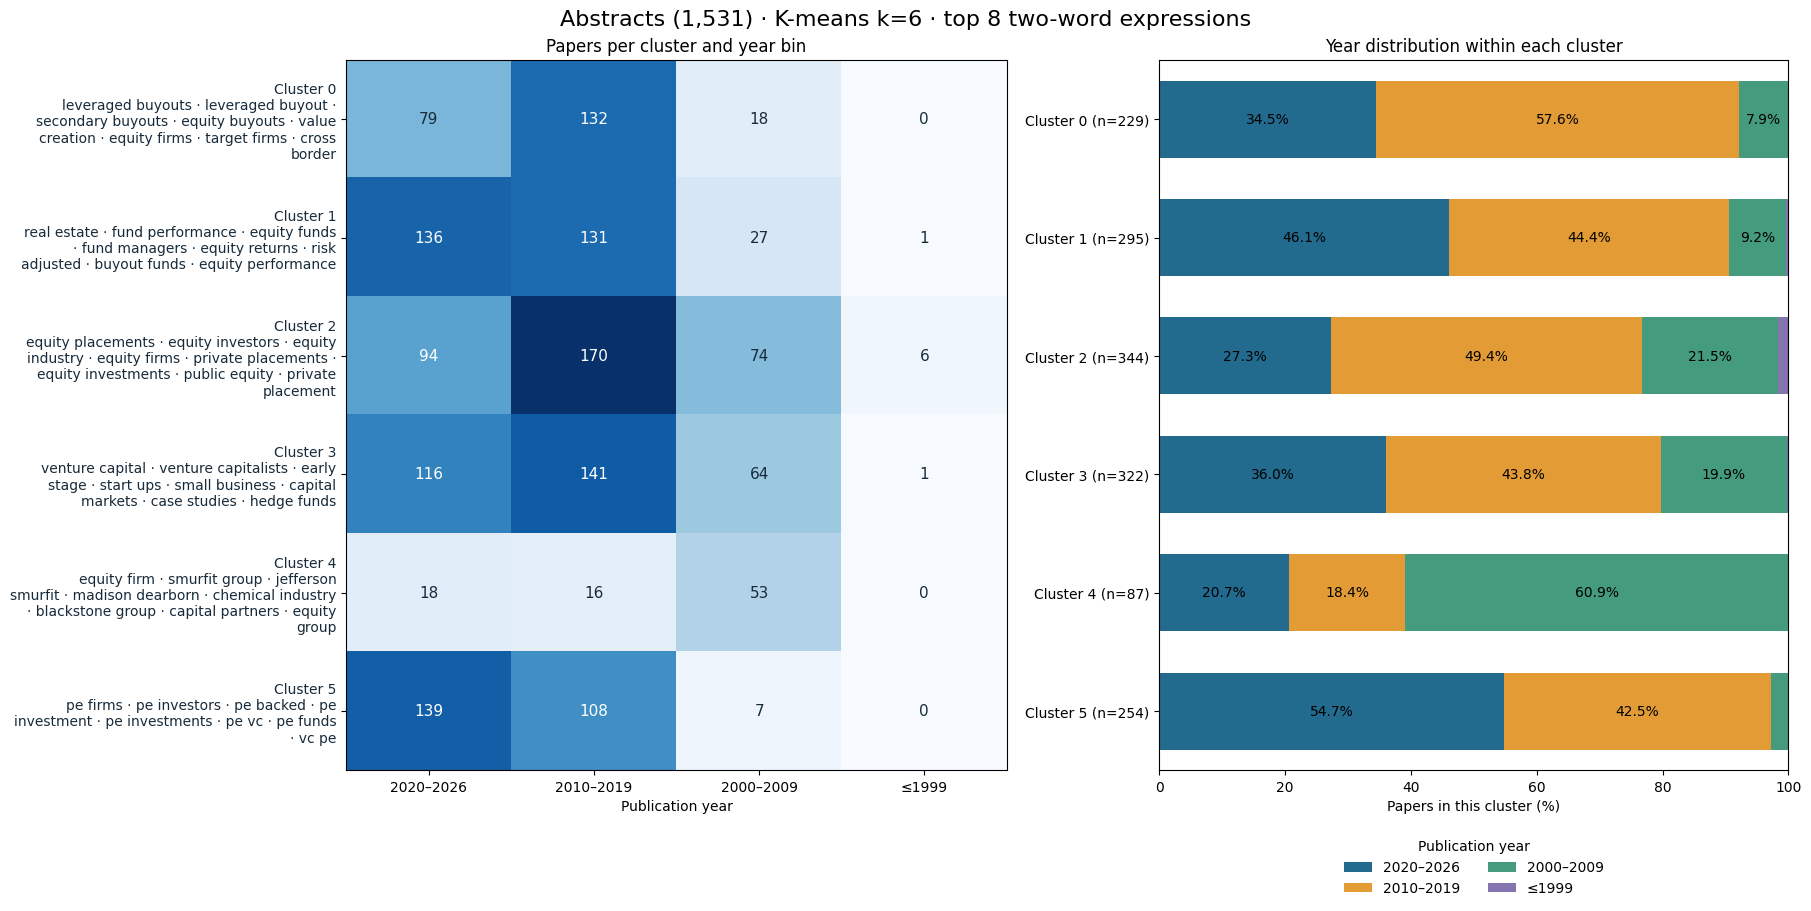

### Citations · Leiden 0.9

period,2020–2026,2010–2019,2000–2009,≤1999
display_cluster,,,,
Cluster 1 — health care · nursing homes · pe owned · nursing home · pe ownership · pe acquisitions · pe firms · physician practices,42 (61.8%),23 (33.8%),1 (1.5%),2 (2.9%)
Cluster 2 — free cash · going private · management buyouts · operating performance · leveraged buyouts · private transactions · lbo firms · operating income,4 (4.1%),57 (58.2%),19 (19.4%),18 (18.4%)
Cluster 3 — financial reporting · financial statement · financial statements · private firms · statement information · reporting quality · backed ipos · external equity,12 (50.0%),4 (16.7%),6 (25.0%),2 (8.3%)
Cluster 4 — buyout funds · vc funds · vintage year · fund size · fund performance · fund level · vintage years · committed capital,33 (34.4%),50 (52.1%),13 (13.5%),0 (0.0%)
Cluster 5 — practice management · physician practice · hospital systems · physician led · market forces · employed physicians · road ahead · physicians foundation,2 (66.7%),1 (33.3%),0 (0.0%),0 (0.0%)


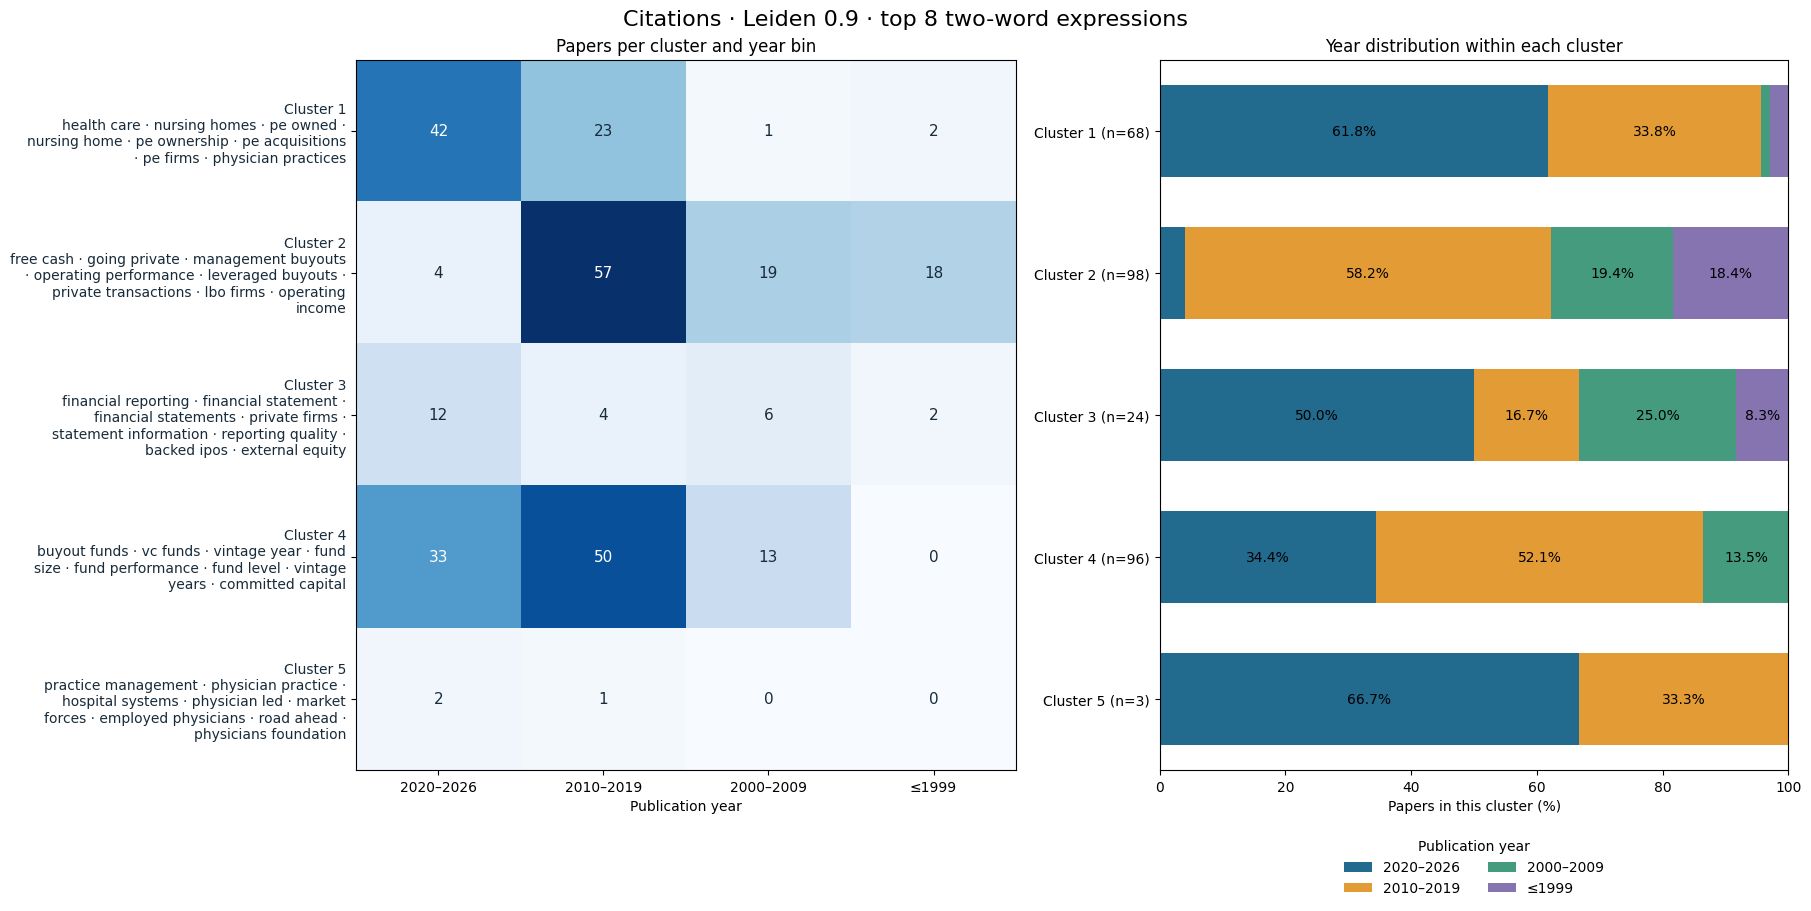

In [4]:
figure_paths = []
for spec in CONFIG['partitions']:
    display(Markdown(f"### {spec['label']}"))
    number_table = bin_matrix(counts, spec['analysis'], spec['solution'], CONFIG['periods'])
    share_table = bin_matrix(counts, spec['analysis'], spec['solution'], CONFIG['periods'], 'share_pct')
    formatted = number_table.astype(str)
    for period in number_table.index:
        for cluster in number_table.columns:
            pct = share_table.loc[period, cluster]
            formatted.loc[period, cluster] = (f'{int(number_table.loc[period, cluster])} ({pct:.1f}%)'
                                              if pd.notna(pct) else '0 (—)')
    display(formatted.T.style.set_caption('Papers (share of papers in this cluster)')
            .set_table_styles([{'selector': 'th.row_heading', 'props': [('max-width', '480px'),
                                                                    ('white-space', 'normal')]}]))
    fig = plot_named_bins(counts, spec, CONFIG['periods'], cluster_names,
                          share_basis=CONFIG['share_basis'])
    basename = f"{spec['analysis']}_{spec['solution']}_by_year_bin"
    for extension in ['png', 'pdf', 'svg']:
        path = FIGURES / f'{basename}.{extension}'
        fig.savefig(path, dpi=200, bbox_inches='tight')
        figure_paths.append(path)
    display(fig)
    plt.close(fig)


## 4 Check the denominators and unassigned works

The first table gives each cluster’s total, used as its percentage denominator.
The year-bin coverage table then accounts for every paper. Citation isolates are retained here and in the
paper-level export, but they are not treated as a sixth cluster. A small community
remains visible in every bin, including bins where it has no papers.


In [5]:
cluster_totals = counts[['analysis', 'solution', 'cluster', 'cluster_papers']].drop_duplicates()
cluster_totals = cluster_totals.merge(selected_partitions[['analysis', 'solution', 'partition']],
                                      on=['analysis', 'solution'], validate='many_to_one')
display(cluster_totals[['partition', 'cluster', 'cluster_papers']].rename(columns={
    'partition': 'Partition', 'cluster': 'Cluster ID',
    'cluster_papers': 'Papers in cluster (percentage denominator)',
}).style.hide(axis='index'))

partition_names = selected_partitions[['analysis', 'solution', 'partition']]
coverage_view = coverage.merge(partition_names, on=['analysis', 'solution'], validate='many_to_one')
display(coverage_view[['partition', 'period', 'period_all_papers',
                       'period_assigned_papers', 'period_unassigned_papers']]
        .rename(columns={'partition': 'Partition', 'period': 'Year bin',
                         'period_all_papers': 'All papers', 'period_assigned_papers': 'Assigned papers',
                         'period_unassigned_papers': 'Unassigned papers'}).style.hide(axis='index'))
unassigned = members.loc[~members.assigned]
display(Markdown(f'**Unassigned citation works: {len(unassigned)}**'))
display(unassigned[['paper_id', 'title', 'publication_year', 'period']].style.hide(axis='index'))


Partition,Cluster ID,Papers in cluster (percentage denominator)
"Abstracts (1,531) · K-means k=6",0,229
"Abstracts (1,531) · K-means k=6",1,295
"Abstracts (1,531) · K-means k=6",2,344
"Abstracts (1,531) · K-means k=6",3,322
"Abstracts (1,531) · K-means k=6",4,87
"Abstracts (1,531) · K-means k=6",5,254
Citations · Leiden 0.9,1,68
Citations · Leiden 0.9,2,98
Citations · Leiden 0.9,3,24
Citations · Leiden 0.9,4,96


Partition,Year bin,All papers,Assigned papers,Unassigned papers
"Abstracts (1,531) · K-means k=6",2020–2026,582,582,0
"Abstracts (1,531) · K-means k=6",2010–2019,698,698,0
"Abstracts (1,531) · K-means k=6",2000–2009,243,243,0
"Abstracts (1,531) · K-means k=6",≤1999,8,8,0
Citations · Leiden 0.9,2020–2026,93,93,0
Citations · Leiden 0.9,2010–2019,137,135,2
Citations · Leiden 0.9,2000–2009,40,39,1
Citations · Leiden 0.9,≤1999,22,22,0
PDFs · Leiden 0.95,2020–2026,93,93,0
PDFs · Leiden 0.95,2010–2019,137,137,0


**Unassigned citation works: 3**

paper_id,title,publication_year,period
P036,Size Management by European Private Firms to Minimize Proprietary Costs of Disclosure,2014,2010–2019
P125,"Boards, CEO entrenchment, and the cost of capital",2013,2010–2019
P315,Institutional liquidity needs and the structure of monitored finance,2003,2000–2009


## 5 Inspect the papers behind one cell

Choose a partition, bin and original cluster ID. The full list explains exactly
which papers contribute to that cell. A zero-count cell correctly yields an empty
list. For citations only, cluster 0 lets you inspect unassigned works.

The selected cluster’s full expression name is displayed above its paper list.


In [6]:
INSPECT_ANALYSIS = 'abstracts'       # 'pdfs', 'abstracts', or 'citations'
INSPECT_SOLUTION = 'kmeans_k6'   # Copy the solution from selected_partitions.
INSPECT_PERIOD = '2020–2026'
INSPECT_CLUSTER = 1

partition = members.loc[members.analysis.eq(INSPECT_ANALYSIS)
                        & members.solution.eq(INSPECT_SOLUTION)]
if partition.empty or INSPECT_CLUSTER not in set(partition.cluster):
    raise ValueError('Choose a partition and original cluster ID from the tables above.')
if INSPECT_PERIOD not in {period['label'] for period in CONFIG['periods']}:
    raise ValueError('Choose a configured year bin.')
display(Markdown('**' + partition.loc[partition.cluster.eq(INSPECT_CLUSTER), 'display_cluster'].iloc[0] + '**'))
selected = partition.loc[partition.period.eq(INSPECT_PERIOD)
                         & partition.cluster.eq(INSPECT_CLUSTER)].sort_values(
                             ['publication_year', 'paper_id'], ascending=[False, True])
denominator = int((partition.cluster.eq(INSPECT_CLUSTER) & partition.assigned).sum())
if denominator:
    print(f'{len(selected)} papers in this bin / {denominator} papers in this cluster '
          f'= {100 * len(selected) / denominator:.1f}% of the cluster.')
else:
    print(f'{len(selected)} unassigned papers in this bin; excluded from cluster percentages.')
display(selected[['paper_id', 'title', 'publication_year', 'doi']]
        .style.hide(axis='index').set_properties(**{'white-space': 'normal'}))


136 papers in this bin / 295 papers in this cluster = 46.1% of the cluster.


**Cluster 1 — real estate · fund performance · equity funds · fund managers · equity returns · risk adjusted · buyout funds · equity performance**

paper_id,title,publication_year,doi
2-s2.0-105006446612,Market efficiency: do listed private equity ETFs adapt?,2026,10.1108/mf-07-2024-0542
2-s2.0-105011359848,The Agency Costs of Side-by-side Management: Evidence from the Hedge Fund and Private Equity Industry,2026,10.1111/1467-8551.70006
2-s2.0-105018089922,Systematic Risk in Publicly Listed Private Equity: An Empirical Study Using Score-Driven Beta Models,2026,10.1515/snde-2025-0085
2-s2.0-105021934080,Market distortions in the Dutch mixed long-term care market: An exploratory analysis,2026,10.1017/s1744133125100248
2-s2.0-105025162055,Do GPs truly present fair value? The case of continuation funds,2026,10.1016/j.intfin.2025.102265
2-s2.0-105029101026,Robust Optimization of Strategic and Tactical Asset Allocation for Multi-Asset Portfolios,2026,10.3905/jpm.2025.1.806
2-s2.0-105029135285,The Tyranny of IRR,2026,10.3905/jpm.2026.1.809
2-s2.0-105031554584,From Opportunity to Constraint: Structural Inequities in Public Pension Fund Investing,2026,10.1111/pbaf.70018
2-s2.0-105035697463,Benchmarking Private Equity Performance When Fund-level Cash Flows are Missing,2026,10.1007/s11146-025-10042-7
2-s2.0-105036365849,Applying the Appraisal Ratio and Style Analysis to Total Portfolio Management,2026,10.3905/jpm.2026.1.824


## 6 Save the bin analysis

The export contains complete paper memberships and publication years, the selected
partition settings, all cluster-by-bin counts and shares, and the denominator audit.
`share_pct` uses the cluster total across all bins, recorded as `cluster_papers`.
The manifest records source checksums, membership identities and year-bin settings.
Figures are saved as PNG, PDF and SVG. All results go to
`reports/topic_age_analysis_v3_test_final/`.

`cluster_expression_names.csv` records the eight ordered expressions per cluster
and their membership/text fingerprints. `cluster_label_evidence.csv` includes
the scores and inside/outside support behind each expression. Paper memberships
and bin tables carry the same names.

The export includes only PDF Leiden 0.95, abstract K-means k=6 (1,531 papers), and citation Leiden 0.9. Earlier outputs are preserved in the archive recorded by the configuration.


In [7]:
cluster_names.to_csv(OUT / 'cluster_expression_names.csv', index=False)
label_evidence.to_csv(OUT / 'cluster_label_evidence.csv', index=False)
exported = export_results(ROOT, OUT, CONFIG, members, selected_partitions,
                          counts, coverage, provenance)
print('Saved tables and manifest:', exported)
print(f'Saved {len(figure_paths)} figure files:', FIGURES)
print('Three partitions: PDF Leiden (5 clusters), abstract K-means (6), citation Leiden (5).')


Saved tables and manifest: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/topic_age_analysis_v3_test_final
Saved 9 figure files: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/topic_age_analysis_v3_test_final/figures
Three partitions: PDF Leiden (5 clusters), abstract K-means (6), citation Leiden (5).
